# Workshop runtime setup

Run the notebook from the project folder. The same setup supports a local Jupyter
kernel and Google Colab. Install the pinned environment once with
`python -m pip install -r requirements-workshop.txt`.

The repository defaults to **dry-run mode**, which keeps every teaching stage but
uses shorter model training and smaller visualization samples. Set the environment
variable `POLYMER_WORKSHOP_DRY_RUN=0` before starting Jupyter for the full workshop
parameters.


In [1]:
from pathlib import Path
import os
import sys

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
except ImportError:
    pass

candidates = []
if os.getenv('POLYMER_WORKSHOP_ROOT'):
    candidates.append(Path(os.environ['POLYMER_WORKSHOP_ROOT']).expanduser())
candidates.extend([
    Path.cwd(),
    Path.cwd().parent,
    Path('/content/drive/MyDrive/SPE'),
])

PROJECT_ROOT = next((p.resolve() for p in candidates if (p / 'Tg.csv').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Cannot find Tg.csv. Start Jupyter in the project folder or set '
        'POLYMER_WORKSHOP_ROOT to the project directory.'
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from workshop_config import *

path = str(PROJECT_ROOT) + os.sep  # Backward-compatible alias used below.
print(f'Project root: {PROJECT_ROOT}')
print(f'Runtime mode: {mode_label()}')


Project root: /path/to/Polymer-Informatics-workshop-ready
Runtime mode: DRY RUN


# Overview of Machine Learning and Polymer Informatics

Authors: Tianle Yue, Laboratory for Polymer Difital Engineering, University of Wisconsin–Madison.

This lab introduces students to an end-to-end example of applying a machine learning (ML) workflow to a polymer informatic dataset to address a research problem. The lab aims at deepening the conceptual understanding of ML, and while procedural skills such as writing Python code are not the focus of this lab, students will gain experience with a number of standard open source packages by interacting with code snippets through the Jupyter Notebook format and describing what each essential command does.

If you're unfamiliar with Jupyter Notebooks, take a moment to read about the lesson format.

## Jupyter Notebook Tips and Tricks

#### Cells
Each individual part of this notebook is known as a cell. The orange highlight bar along the left edge of this page indicates which cell is active.

#### Moving between active cells
You can move between cells by hitting the `up` and `down` arrows or by clicking on the cell you want to focus on. The `up` and `down` arrow keys will only move you between cells when you are not in edit mode.

#### Edit mode
Hit the `enter` key on the active cell to "enter" it and edit its contents. While in edit mode, the `up` and `down` arrow keys will not move you between cells. Double clicking a cell will also enable edit mode.

#### Running a cell
Hit `shift + enter` to run the active cell. In a code cell, the code will run and if there is output, it will be displayed immediately below the code cell. In a markdown cell, the markdown will be rendered. Running a cell will automatically make the following cell the new active cell.

####  Exit edit mode
If you're editing a cell and want to exit edit mode, hit the `esc` key. This will exit edit mode, but the current cell will still be the active cell. This action will not run the cell. It will enable you to use the `up` and `down` arrow keys to move between cells again.

#### Adding a cell
When you're not in edit mode, hit `b` to add a new cell. The new cell will be added directly below the active cell.

#### Deleting a cell
When you're not in edit mode, hit `x` to delete the active cell.

#### Switching between markdown and code
When you're not in edit mode, you can convert a code cell to a markdown cell by hitting the `m` key, and convert a markdown cell to a code cell by hitting the `c` key.

## Python Packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from math import sqrt

from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv1D, MaxPooling1D, Dense, Flatten, Activation
import time
from sklearn.metrics import r2_score

from collections import Counter
import pickle
import collections
import seaborn as sns

from rdkit import rdBase
rdBase.DisableLog('rdApp.warning')

## Background

### Glass transition temperature

The glass transition temperature $T_g$ of a material characterizes the range of temperatures over which this glass transition occurs (as an experimental definition, typically marked as 100 s of relaxation time). It is always lower than the melting temperature, $T_m$, of the crystalline state of the material, if one exists, because the glass is a higher energy state (or enthalpy at constant pressure) than the corresponding crystal.

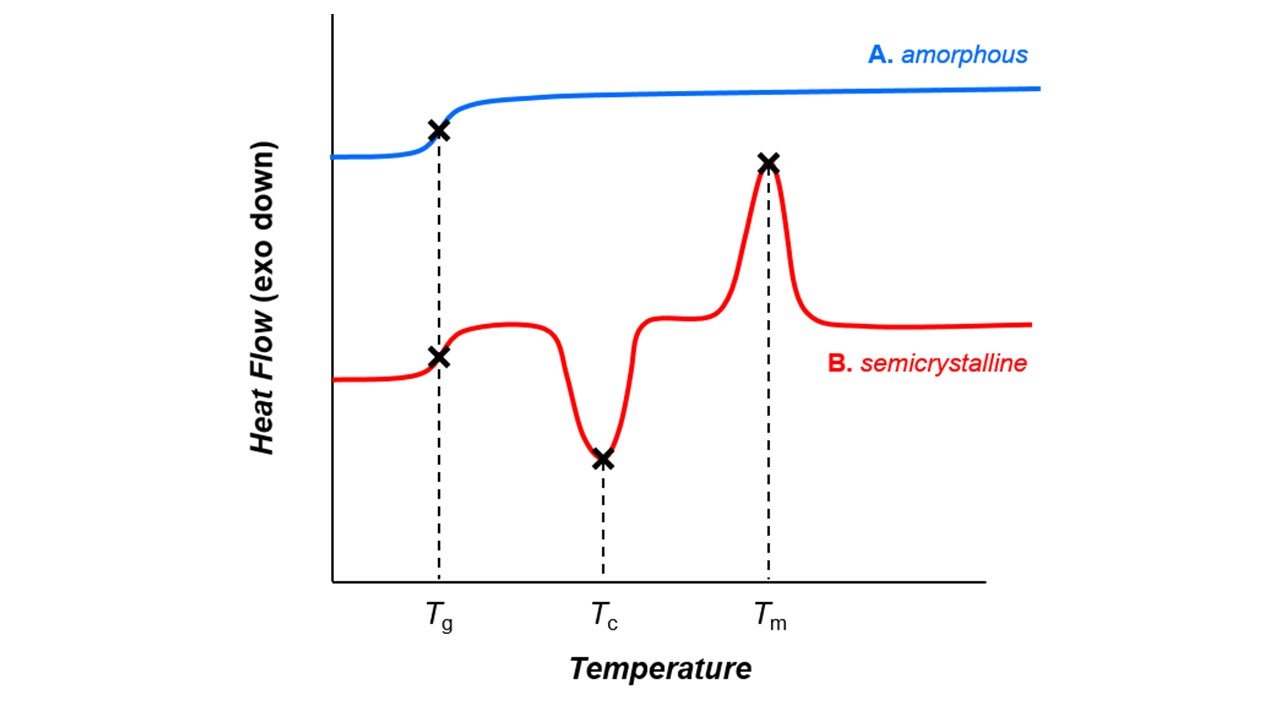

Typical Differential Scanning Calorimeter (DSC) heat flow for an amorphous and a semi-crystalline polymer (exothermic). With the help of DSC it is possible to determine thermal transitions of polymers in a range of temperatures between –180 and +600 °C.


### Glass transition temperature Dataset

The Glass transition temperature dataset used in this study was collected from the PolyInfo dataset (https://polymer.nims.go.jp/). Polymer Database "PoLyInfo" systematically provides various data required for polymeric material design. The main data source is academic literature on polymers. To access the PolyInfo dataset, the domain name of your email address must be registered in our management list.

The reason for using Tg as an example is twofold: first, this property is extremely important for polymer materials, and second, there are many samples available to train our network. This makes training the network less challenging, making it an excellent starting point for learning the integration of ML and polymer informatics.

## Data Inspection

Before getting started, let's first get to know the dataset we'll be working with a little. We'll be taking a look at what information is contained in each column, and how we can use that information to set ourselves up for success later when we start building our machine learning models.

### Importing the Dataset

Through out this lab, you will see many objects in the code named as _df, which stands for dataframe, the primary data structure from the pandas package. It is similar to a spreadsheet or a table.

We won't discuss dataframe operations in detail in this lab. However, external resources are available for you to familiarize yourself with dataframes such as this introduction and the pandas documentation.

In [3]:
# Read in the Tg data
Tg_df = pd.read_csv(os.path.join(path,"Tg.csv"))

In [4]:
# View the dataset (dataframe)
Tg_df

,Smiles,Tg(C)
0,*C*,-63.48
1,*C(C*)C,-2.73
2,*C(C*)CC,-22.54
3,*C(C*)CCC,-32.29
4,*C(C*)C(C)C,10.97
...,...,...
6901,*C1C(C(C(C1)(O)C(F)(F)F)(F)F)(C(C*)(F)F)F,152.00
6902,*C1C(CC(C1)CC(O)(C(F)(F)F)C(F)(F)F)(C(C*)(F)F)F,98.00
6903,*C1C(CC(C1)C(O)(C(F)(F)F)C(F)(F)F)(C(C*)(F)F)F,118.00
6904,*c1cc2C3(CCC(CC3)(C3=NC(CO3)c3ccccc3)C3=NC(CO3...,161.00


Text(0, 0.5, 'Count')

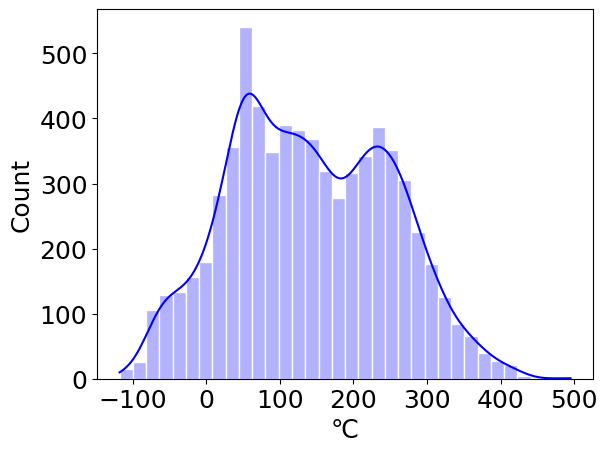

In [5]:
# View the distribution of dataset labels
# Set keyword arguments for the histogram plot, including transparency and edge color
kwargs = dict(hist_kws={'alpha':.3, 'edgecolor':'white'})

# Plot the distribution of the 'Tg(C)' column from Tg_df
sns.histplot(Tg_df['Tg(C)'].dropna(), kde=True, color = 'blue', alpha = 0.3, edgecolor='white')
# Set the font size for the x and y axis ticks
plt.xticks(size=18)
plt.yticks(size=18)
plt.xlabel("℃",fontsize=18)
plt.ylabel("Count",fontsize=18)

*C(C*)CC


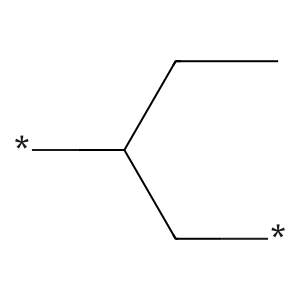

In [6]:
# View molecular structures in the dataset
smiles = Tg_df['Smiles'][2]
print(smiles)
molecule = Chem.MolFromSmiles(smiles)
Draw.MolToImage(molecule)

### Feature Engineering

The goal of feature engineering is to identify structural features that strongly correlate with the properties of the polymer. Feature engineering is the process of using domain knowledge to select, modify, or create new features from raw data—specifically, polymer structure representation—to increase the predictive power of machine learning algorithms.

#### Morgan fingerprint

Molecular fingerprints are a way to represent molecules as mathematical objects. By doing this, we can perform statistical analyses and/or ML techniques on the set of molecules. One of the most popular molecular fingerprinting methods is Extended Connectivity Fingerprinting (ECFP). The ECFP, commonly referred as the Morgan fingerprint, is named after its developer, Robert S. Morgan. These fingerprints are a type of circular feature used for molecular feature engineering method.

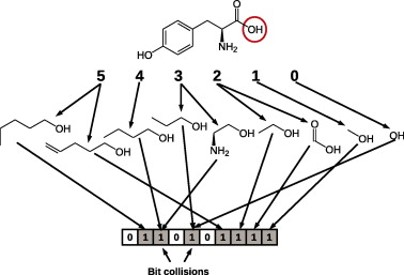

In [7]:
# Generation of Morgan fingerprint

fn = Tg_df.Smiles.apply(Chem.MolFromSmiles).apply(lambda m: AllChem.GetMorganFingerprintAsBitVect(m, radius=3, nBits=1024))

# Convert the Morgan fingerprints into a DataFrame with 1024 columns.
MF = pd.DataFrame()
columns = []
for i in range(1024):
    col_name = f'Bit_{i+1}'
    new_column = fn.apply(lambda x: int(bool(x.GetBit(i))))
    columns.append(pd.Series(new_column, name=col_name))
MF = pd.concat([MF] + columns, axis=1)
MF

,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,Bit_8,Bit_9,Bit_10,...,Bit_1015,Bit_1016,Bit_1017,Bit_1018,Bit_1019,Bit_1020,Bit_1021,Bit_1022,Bit_1023,Bit_1024
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6901,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
6902,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
6903,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
6904,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


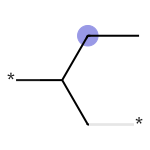

In [8]:
# View the substructure represented by each bit of the Morgan Fingerprint

# Select a specific bit
bit = 0
# Loop through the first 6000 molecules in the dataset
for i in range(len(Tg_df)):
    # Convert the SMILES string to a molecule object
    mol = Chem.MolFromSmiles(Tg_df.loc[i,'Smiles'])
    # Get the bit information of the Morgan fingerprint
    info={}
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, 3, nBits=1024, bitInfo=info)
    # Check if the selected bit is present in the fingerprint information
    if bit in info:

        submols = []
        for atom_idx, radius in info[bit]:
            if 1:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
                atoms = set(Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx))
                submols.append(Chem.PathToSubmol(mol, env))

        # Display the substructures corresponding to the selected bit
        for submol in submols:
            display(Draw.DrawMorganBit(mol,bit,info))

        break


The central atom of the substructures is highlighted in purple, aromatic atoms are highlighted in yellow, other atoms and bonds are highlighted in gray.

*C(C*)CC


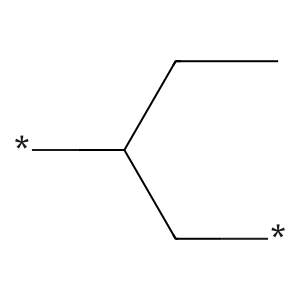

In [9]:
# View molecular structures in the dataset
smiles = Tg_df['Smiles'][2]
print(smiles)
molecule = Chem.MolFromSmiles(smiles)
Draw.MolToImage(molecule)

#### Morgan fingerprint with frequency

Morgan fingerprint with frequency not only identifies the presence of specific molecular features within the fingerprint but also encodes the frequency of these features, thereby enhancing the representation of polymer structures.

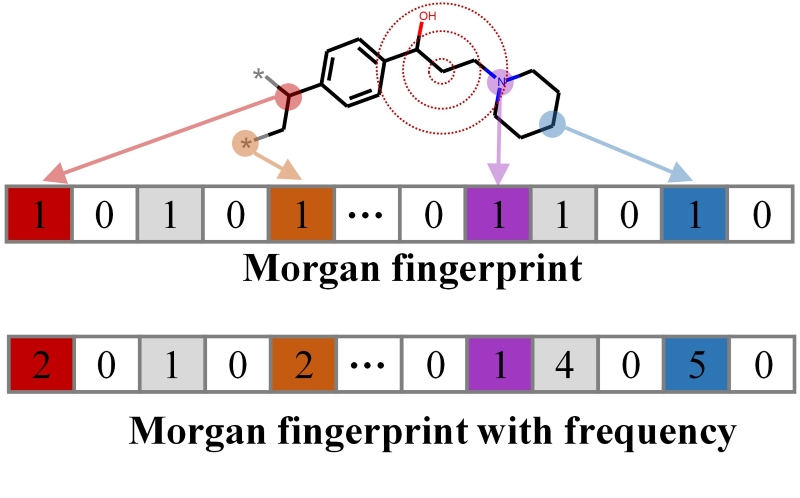

In [10]:
# Count all the substructure information

# Convert SMILES strings in 'Tg_df.Smiles' to RDKit molecule objects
molecules = Tg_df.Smiles.apply(Chem.MolFromSmiles)

# Generate Morgan fingerprints for each molecule with a radius of 3
fp = molecules.apply(lambda m: AllChem.GetMorganFingerprint(m, radius=3))

# Get the non-zero elements from the fingerprints (i.e., the bits that are set)
fp_n = fp.apply(lambda m: m.GetNonzeroElements())

# Initialize an empty list to store the hash codes (bit identifiers)
HashCode = []
for i in fp_n:
    for j in i.keys():
        HashCode.append(j)

# Get unique hash codes and convert them into a list
unique_set = set(HashCode)
unique_list = list(unique_set)

# Create a DataFrame to map unique hash codes to their indices
Corr_df = pd.DataFrame(unique_list).reset_index()

# Initialize an empty list to store the fingerprint vectors
MY_finger = []
for polymer in fp_n:
    my_finger = [0] * len(unique_list)
    for key in polymer.keys():
        index = Corr_df[Corr_df[0] == key]['index'].values[0]
        my_finger[index] = polymer[key]
    MY_finger.append(my_finger)

# Convert the list of fingerprint vectors into a DataFrame
MFF = pd.DataFrame(MY_finger)
MFF

,0,1,2,3,4,5,6,7,8,9,...,26281,26282,26283,26284,26285,26286,26287,26288,26289,26290
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6901,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6902,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6903,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6904,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# filter input into the most popular X substructures

# Count the number of zeros in each column of the DataFrame
Zero_Sum = (MFF == 0).astype(int).sum()

# Set a threshold for the number of zeros in a column
NumberOfZero = 6870

# Print the number of columns with fewer zeros than the threshold
print(len(Zero_Sum[Zero_Sum < NumberOfZero]))

1210


In [12]:
# Generate the Morgan fingerprint with frequency after determining the number of dimensions

Columns = Zero_Sum[Zero_Sum < NumberOfZero].index
Substructure_list = list(polymer.keys())
MFF = MFF[Columns]
MFF

,15,36,127,142,169,205,210,240,243,259,...,26115,26117,26127,26137,26154,26162,26199,26215,26231,26286
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6901,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6902,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6903,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6904,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


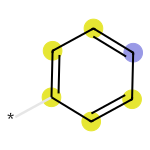

In [13]:
# View the substructure represented by each bit of the Morgan Fingerprint

# Select a specific bit
bit = 399
for i in range(len(Tg_df)):
    mol = Chem.MolFromSmiles(Tg_df.loc[i,'Smiles'])
    # Get the bit information of the Morgan fingerprint
    bi = {}
    fp = rdMolDescriptors.GetMorganFingerprint(mol, radius=3, bitInfo=bi)
    fp_n = fp.GetNonzeroElements()
    Code = (Corr_df[Corr_df['index'] == bit][0].values[0])
    if Code in fp_n.keys():
        img = Draw.DrawMorganBit(mol,Code,bi)

        break
img

The central atom of the substructures is highlighted in purple, aromatic atoms are highlighted in yellow, other atoms and bonds are highlighted in gray.

*C(C*)CC1CCCCC1


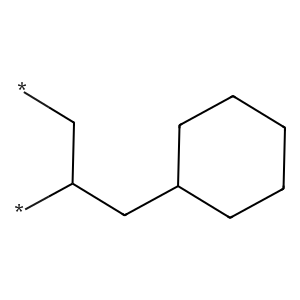

In [14]:
# View molecular structures in the dataset
smiles = Tg_df['Smiles'][20]
print(smiles)
molecule = Chem.MolFromSmiles(smiles)
Draw.MolToImage(molecule)

In [15]:
#Save the generated information for future reproduction of the same Morgan fingerprint with frequency.

pickle_out = open(PROJECT_ROOT / "Corr_All.pickle", "wb")
pickle.dump(Corr_df, pickle_out)
pickle_out.close()

pickle_out = open(PROJECT_ROOT / "unique_list_All.pickle", "wb")
pickle.dump(unique_list, pickle_out)
pickle_out.close()

pickle_out = open(PROJECT_ROOT / "polymer.keys_All.pickle", "wb")
pickle.dump(Substructure_list, pickle_out)
pickle_out.close()

pickle_out = open(PROJECT_ROOT / "Columns_All.pickle", "wb")
pickle.dump(Columns, pickle_out)
pickle_out.close()

#### Descriptors

Descriptors represent another popular method for feature representation in the fields of ML and polymer informatics. These are quantifiable attributes or features of a molecule that can be calculated using various chemical and physical properties. Descriptors provide a way to numerically represent the characteristics of molecules in a format that ML models can efficiently process.

In [16]:
def calculate_all_descriptors(smiles):
    """
    Calculate all molecular descriptors for a molecule given its SMILES representation.

    Parameters:
    smiles (str): The SMILES string representing the molecule.

    Returns:
    dict: A dictionary containing all the calculated molecular descriptors. Returns None if the molecule cannot be generated.
    """
    # Generate a molecule object from the SMILES string
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        # If the molecule object is successfully created, calculate molecular descriptors
        descriptors = {}
        # Iterate over all molecular descriptor functions
        for descriptor_name, descriptor_function in Descriptors.descList:
            try:
                # Attempt to calculate each descriptor and store its value in the dictionary
                descriptors[descriptor_name] = descriptor_function(mol)
            except:
                # If calculation fails, set the descriptor's value to None
                descriptors[descriptor_name] = None
        return descriptors
    else:
        # If the molecule object cannot be generated, return None
        return None
# Apply the calculate_all_descriptors function to each SMILES string in the 'Smiles' column of Tg_df
descriptors_df = Tg_df['Smiles'].apply(lambda x: calculate_all_descriptors(x))
# Convert the list of descriptor dictionaries into a DataFrame where each row represents the descriptors for a molecule
descriptors_df = pd.DataFrame(descriptors_df.tolist())
# Display the resulting DataFrame with molecular descriptors
descriptors_df

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,1.750000,1.750000,0.875000,0.875000,0.355446,20.000000,14.027,12.011,14.015650,6,...,0,0,0,0,0,0,0,0,0,0
1,2.395833,2.395833,0.750000,0.750000,0.414720,25.666667,42.081,36.033,42.046950,18,...,0,0,0,0,0,0,0,0,0,0
2,2.332824,2.332824,0.743056,0.743056,0.451401,22.250000,56.108,48.044,56.062600,24,...,0,0,0,0,0,0,0,0,0,0
3,2.310000,2.310000,0.734306,0.734306,0.476641,20.200000,70.135,60.055,70.078250,30,...,0,0,0,0,0,0,0,0,0,0
4,2.374491,2.374491,0.699074,0.699074,0.465496,21.400000,70.135,60.055,70.078250,30,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6901,14.230116,14.230116,1.115390,-5.853856,0.764710,44.411765,270.119,264.071,270.029091,100,...,0,0,0,0,0,0,0,0,0,0
6902,14.610956,14.610956,0.457778,-6.005614,0.762588,33.809524,330.190,319.102,330.066619,124,...,0,0,0,0,0,0,0,0,0,0
6903,14.547685,14.547685,0.782397,-6.107007,0.783068,34.900000,316.163,307.091,316.050969,118,...,0,0,0,0,0,0,0,0,0,0
6904,6.761067,6.761067,0.026076,-0.514062,0.096597,23.661538,855.179,792.683,854.481129,328,...,0,0,0,0,0,0,0,0,4,0


The specific meanings of the descriptors in the dataframe can be found at the following URL： https://www.rdkit.org/docs/Cartridge.html#descriptors

##### Remove constant columns

Columns that have a constant value for all data points have no information and can't possibly help the ML model learn anything.

In [17]:
# Remove Constant Columns
descriptors_df_noconstant = descriptors_df.loc[:, (descriptors_df != descriptors_df.iloc[0]).any()]
descriptors_df_noconstant = descriptors_df_noconstant.dropna(axis=1, how='any')
# report number of columns
len(descriptors_df_noconstant.columns)

187

##### Remove highly correlated features

Features that are extremely similar don't give any additional information beyond the first appearance.  
They can also confuse the model by giving very similar information that may essentially overload the model.  
Before we remove features, let's calculate the correlation matrix for all the features.

In [18]:
# Remove Highly correlated Features
# using notes here for methodology: https://chrisalbon.com/machine_learning/feature_selection/drop_highly_correlated_features/

descriptors_corr_df = descriptors_df_noconstant.corr(method="pearson").abs()

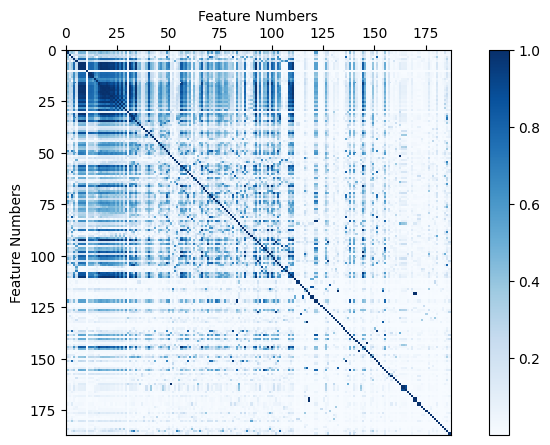

In [19]:
# before removing correlated features
fig1, ax1 = plt.subplots(figsize=(10,5))
c = ax1.pcolor(descriptors_corr_df,cmap="Blues")
ax1.set_ylim(ax1.get_ylim()[::-1])
ax1.xaxis.set_ticks_position('top')
ax1.xaxis.set_label_position('top')
ax1.set_xlabel('Feature Numbers')
ax1.set_ylabel('Feature Numbers')
ax1.set_aspect('equal')
plt.colorbar(c,ax=ax1)
plt.show()

In [20]:
# Filter the features with correlation coefficients above 0.95
upper = descriptors_corr_df.where(np.triu(np.ones(descriptors_corr_df.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
descriptors_df_lowcorr = descriptors_df_noconstant.drop(columns=to_drop)
# recalculate the correlation matrix so we can compare
descriptors_corr_df_update = descriptors_df_lowcorr.corr(method="pearson").abs()

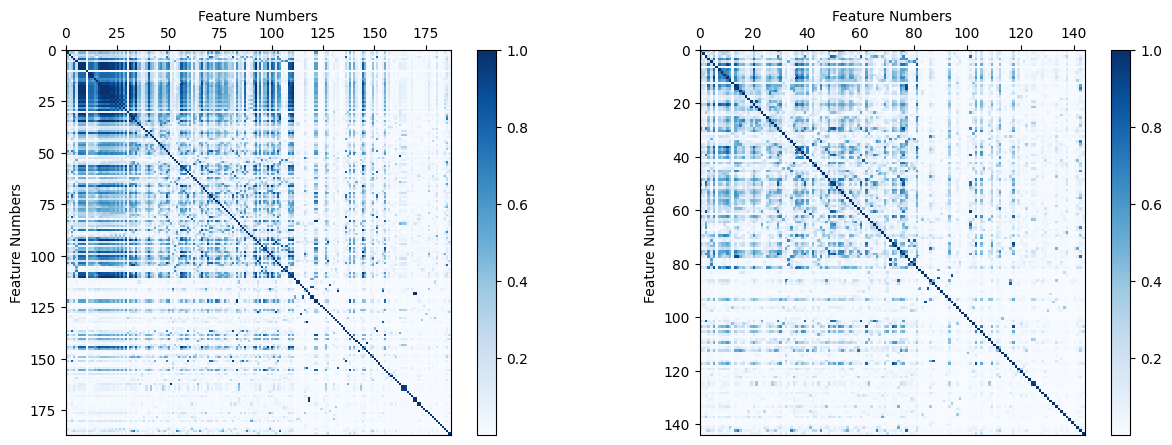

In [21]:
# plot correlation after removing highly correlated features

fig1, (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))
c1 = ax1.pcolor(descriptors_corr_df,cmap="Blues")
ax1.set_ylim(ax1.get_ylim()[::-1])
ax1.xaxis.set_ticks_position('top')
ax1.xaxis.set_label_position('top')
ax1.set_xlabel('Feature Numbers')
ax1.set_ylabel('Feature Numbers')
ax1.set_aspect('equal')

plt.colorbar(c1,ax=ax1)

c2 = ax2.pcolor(descriptors_corr_df_update,cmap="Blues")
ax2.set_ylim(ax2.get_ylim()[::-1])
ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')
ax2.set_xlabel('Feature Numbers')
ax2.set_ylabel('Feature Numbers')
ax2.set_aspect('equal')
plt.colorbar(c2,ax=ax2)
plt.show()

In [22]:
len(descriptors_df_lowcorr.columns)

144

##### Feature Normalization

Finally the last thing that we need to do is perform some normalization or rescaling of our features.

It should be fairly apparent that our features come in many shapes and sizes. Machine Learning algorithms can be very sensitive to these differences.
For example one feature may be several orders of magnitude larger in values and in range of values.
This can make some algorithms significantly biased towards those features so the best practice is usually to perform some alteration to make all the features look similar, while still preserving the information they contain

In our case we're going to linearly rescale the features so that they all have the same minimum and same maximum. If you're interested in checking of the details of how this is done you can check out the documentation for the Scikit-learn method we'll be using: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

In [23]:
descriptors_df_lowcorr

,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,NumRadicalElectrons,FpDensityMorgan1,AvgIpc,BalabanJ,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,1.750000,0.875000,0.875000,0.355446,20.000000,14.027,0,4.000000,0.918296,1.632993,...,0,0,0,0,0,0,0,0,0,0
1,2.395833,0.750000,0.750000,0.414720,25.666667,42.081,0,3.000000,1.378783,2.539539,...,0,0,0,0,0,0,0,0,0,0
2,2.332824,0.743056,0.743056,0.451401,22.250000,56.108,0,2.500000,1.650022,2.754185,...,0,0,0,0,0,0,0,0,0,0
3,2.310000,0.734306,0.734306,0.476641,20.200000,70.135,0,2.200000,1.679823,2.831820,...,0,0,0,0,0,0,0,0,0,0
4,2.374491,0.699074,0.699074,0.465496,21.400000,70.135,0,2.000000,1.645711,3.144208,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6901,14.230116,1.115390,-5.853856,0.764710,44.411765,270.119,0,1.235294,2.378449,3.484734,...,0,0,0,0,0,0,0,0,0,0
6902,14.610956,0.457778,-6.005614,0.762588,33.809524,330.190,0,1.095238,2.627781,3.075549,...,0,0,0,0,0,0,0,0,0,0
6903,14.547685,0.782397,-6.107007,0.783068,34.900000,316.163,0,1.100000,2.632632,3.299603,...,0,0,0,0,0,0,0,0,0,0
6904,6.761067,0.026076,-0.514062,0.096597,23.661538,855.179,0,0.476923,4.174353,0.989347,...,0,0,0,0,0,0,0,0,4,0


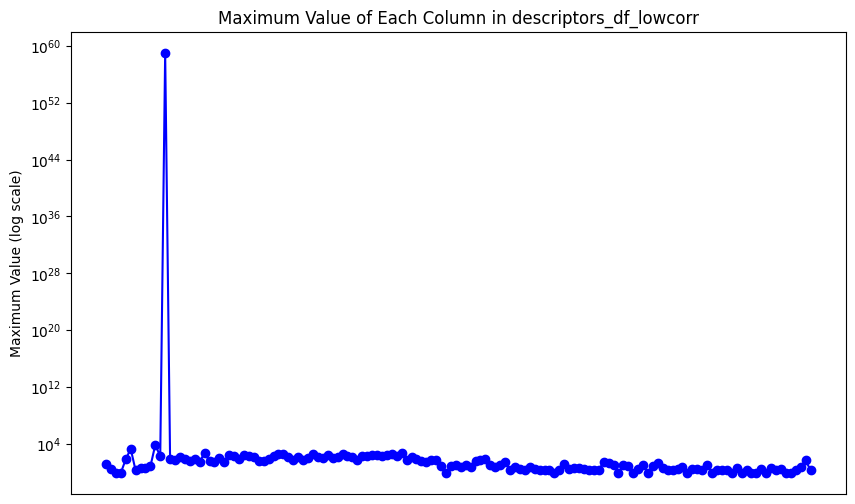

In [24]:
max_values = descriptors_df_lowcorr.max()

plt.figure(figsize=(10, 6))
plt.plot(max_values, marker='o', linestyle='-', color='b')
plt.yscale('log')

plt.title('Maximum Value of Each Column in descriptors_df_lowcorr')
plt.ylabel('Maximum Value (log scale)')

plt.xticks([])

plt.show()

In [25]:
# Apply Min-Max scaling to normalize the descriptors data
# MinMaxScaler scales the features to a range between 0 and 1
minmax_descriptors = MinMaxScaler().fit_transform(descriptors_df_lowcorr)
# Convert the normalized descriptors back into a DataFrame
# The column names are preserved from the original DataFrame
minmax_descriptors_df = pd.DataFrame(minmax_descriptors,columns=descriptors_df_lowcorr.columns)

In [26]:
minmax_descriptors_df

,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,NumRadicalElectrons,FpDensityMorgan1,AvgIpc,BalabanJ,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0.004263,0.255605,1.000000,0.386171,0.161195,0.000000,0.0,0.919831,0.061113,0.168029,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.045281,0.219090,0.988061,0.452004,0.247814,0.012819,0.0,0.679325,0.182238,0.298480,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.041279,0.217061,0.987397,0.492744,0.195588,0.019229,0.0,0.559072,0.253583,0.329368,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.039829,0.214505,0.986562,0.520777,0.164252,0.025638,0.0,0.486920,0.261422,0.340539,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.043925,0.204213,0.983197,0.508399,0.182595,0.025638,0.0,0.438819,0.252449,0.385492,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6901,0.796884,0.325828,0.357296,0.840723,0.534347,0.117020,0.0,0.254902,0.445185,0.434493,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
6902,0.821072,0.133725,0.342801,0.838366,0.372284,0.144469,0.0,0.221218,0.510768,0.375612,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
6903,0.817053,0.228554,0.333116,0.861113,0.388953,0.138059,0.0,0.222363,0.512044,0.407853,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
6904,0.322520,0.007616,0.867324,0.098678,0.217164,0.384359,0.0,0.072509,0.917571,0.075409,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.074074,0.0


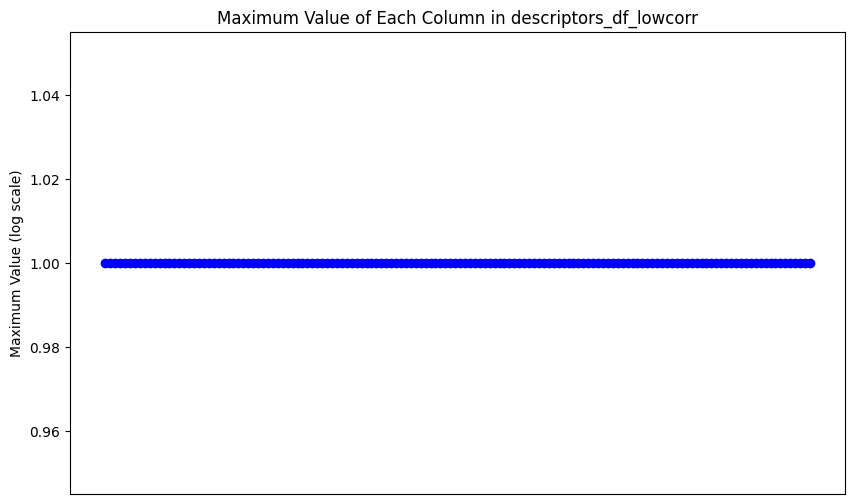

In [27]:
max_values = minmax_descriptors_df.max()

plt.figure(figsize=(10, 6))
plt.plot(max_values, marker='o', linestyle='-', color='b')


plt.title('Maximum Value of Each Column in descriptors_df_lowcorr')
plt.ylabel('Maximum Value (log scale)')

plt.xticks([])

plt.show()